In [ ]:
!pip install tensorflow matplotlib numpy scipy scikit-learn seaborn -q

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# resize=0.4 gives 50x37 images — this is what got 97% in your notebook!
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

print("Dataset shape     :", lfw.images.shape)
print("Number of classes :", lfw.target_names.shape[0])
print("People            :", lfw.target_names)
print()
print("Images per person:")
for i, name in enumerate(lfw.target_names):
    print(f"  {name}: {np.sum(lfw.target == i)}")

Dataset shape     : (1288, 50, 37)
Number of classes : 7
People            : ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']

Images per person:
  Ariel Sharon: 77
  Colin Powell: 236
  Donald Rumsfeld: 121
  George W Bush: 530
  Gerhard Schroeder: 109
  Hugo Chavez: 71
  Tony Blair: 144


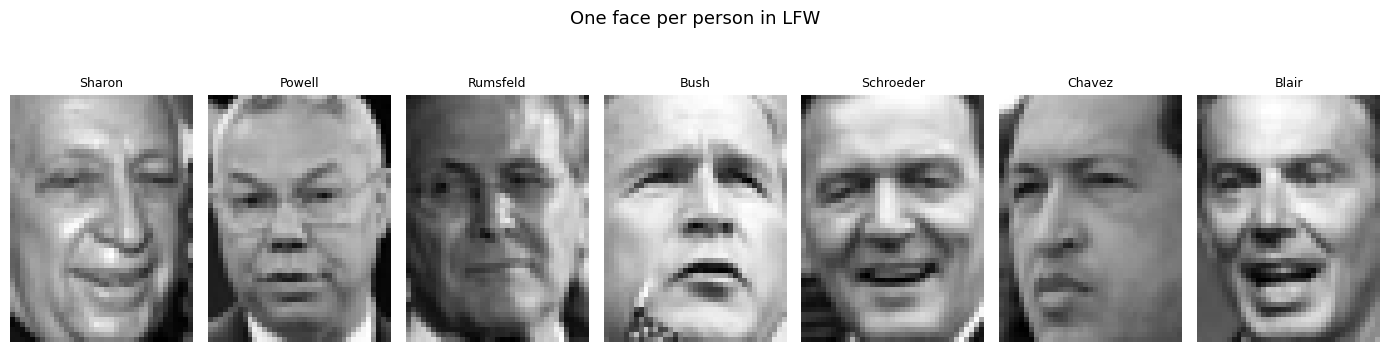

In [ ]:
plt.figure(figsize=(14, 4))
for i in range(7):
    plt.subplot(1, 7, i+1)
    # find first image of each person
    idx = np.where(lfw.target == i)[0][0]
    plt.imshow(lfw.images[idx], cmap='gray')
    plt.title(lfw.target_names[i].split()[-1], fontsize=9)
    plt.axis('off')
plt.suptitle("One face per person in LFW", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
x = lfw.images   # already normalized 0-1 by sklearn
y = lfw.target

# reshape for CNN: (samples, height, width, channels)
x = x.reshape(-1, 50, 37, 1)

# stratified split — ensures each class proportionally in train/test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# compute class weights to fix the imbalance (Bush=530, Chavez=71)
cw = class_weight.compute_class_weight('balanced',
                                        classes=np.unique(y_train),
                                        y=y_train)
cw_dict = dict(enumerate(cw))

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)
print("Class weights:", cw_dict)

Train shape: (1030, 50, 37, 1)
Test shape : (258, 50, 37, 1)
Class weights: {0: np.float64(2.4121779859484778), 1: np.float64(0.7785336356764928), 2: np.float64(1.5169366715758468), 3: np.float64(0.3470350404312669), 4: np.float64(1.6912972085385878), 5: np.float64(2.581453634085213), 6: np.float64(1.279503105590062)}


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train)
print("Augmentation ready")

Augmentation ready ✅


In [ ]:
num_classes = len(lfw.target_names)

model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(50, 37, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Block 4
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    # Fully connected
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',  # no need for one-hot this way
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 37, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 37, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 9, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 9, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 9, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 9, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 685,031 (2.61 MB)

 Trainable params: 683,111 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
callbacks_list = [
    ModelCheckpoint('best_model.keras', save_best_only=True,
                    monitor='val_accuracy', mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=8,
                      min_lr=1e-6, verbose=1, mode='max'),
    EarlyStopping(monitor='val_accuracy', patience=20,
                  restore_best_weights=True, verbose=1, mode='max')
]

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=80,
    validation_data=(x_test, y_test),
    callbacks=callbacks_list,
    class_weight=cw_dict   # ← fixes the Bush-dominance collapse
)

Epoch 1/80
30/33 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.1458 - loss: 3.0926
Epoch 1: val_accuracy improved from None to 0.08527, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 385ms/step - accuracy: 0.1398 - loss: 2.9792 - val_accuracy: 0.0853 - val_loss: 1.9422 - learning_rate: 0.0010
Epoch 2/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1673 - loss: 2.8151
Epoch 2: val_accuracy improved from 0.08527 to 0.11628, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1621 - loss: 2.7163 - val_accuracy: 0.1163 - val_loss: 1.9298 - learning_rate: 0.0010
Epoch 3/80
30/33 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1709 - loss: 2.6053
Epoch 3: val_accuracy did not improve from 0.11628
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1573 - loss: 2.6995 - val_accuracy: 0.0853 - val_loss: 2.1814 - learning_rate:

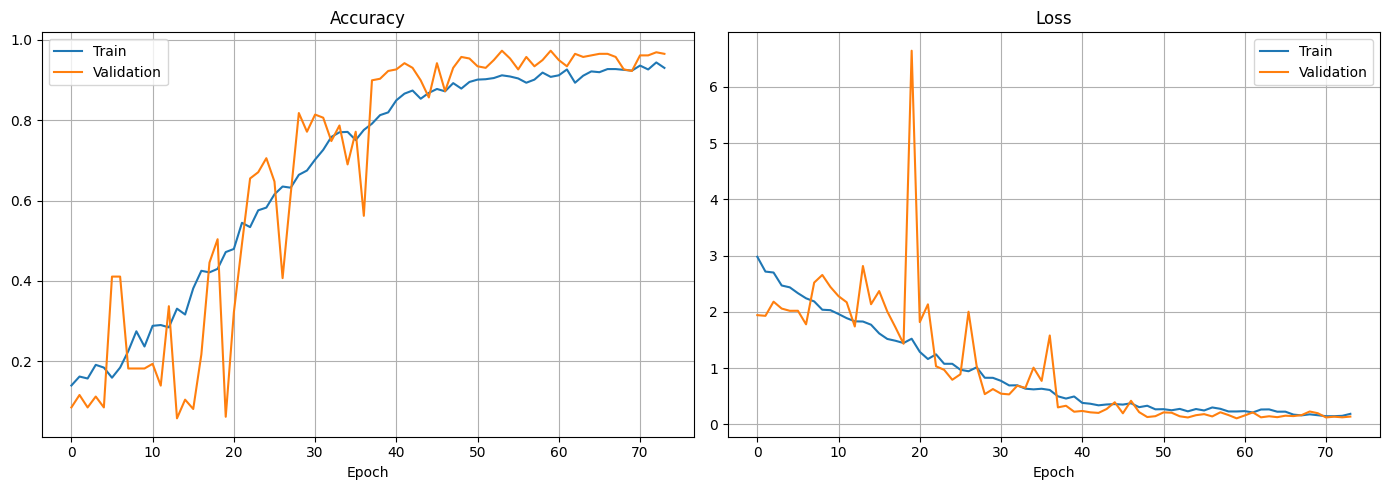

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9729 - loss: 0.1240

✅ Test Accuracy: 97.29%
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step

Classification Report:
              precision    recall  f1-score   support

      Sharon       0.94      1.00      0.97        16
      Powell       0.98      1.00      0.99        47
    Rumsfeld       0.92      0.96      0.94        24
        Bush       0.98      0.98      0.98       106
   Schroeder       0.96      1.00      0.98        22
      Chavez       1.00      1.00      1.00        14
       Blair       1.00      0.86      0.93        29

    accuracy                           0.97       258
   macro avg       0.97      0.97      0.97       258
weighted avg       0.97      0.97      0.97       258



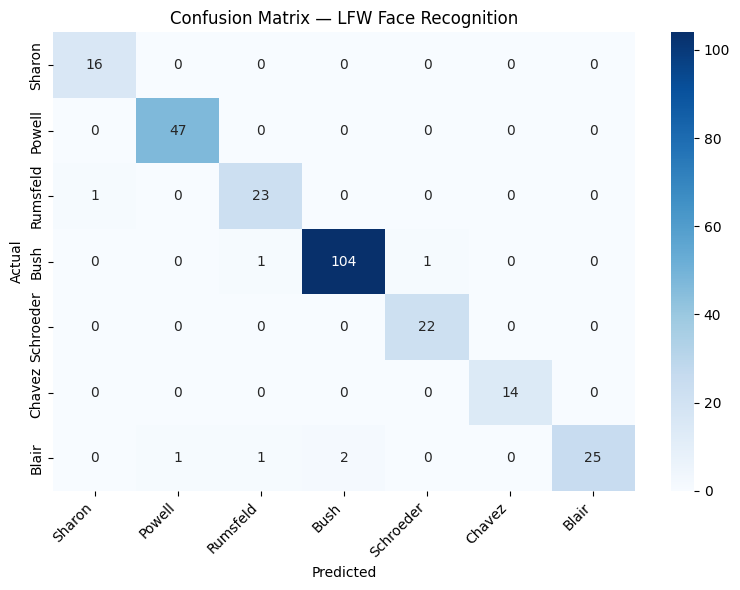

In [ ]:
best_model = tf.keras.models.load_model('best_model.keras')
test_loss, test_accuracy = best_model.evaluate(x_test, y_test)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")

y_pred = np.argmax(best_model.predict(x_test), axis=1)
short_names = [name.split()[-1] for name in lfw.target_names]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=short_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names)
plt.title('Confusion Matrix — LFW Face Recognition')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 937ms/step


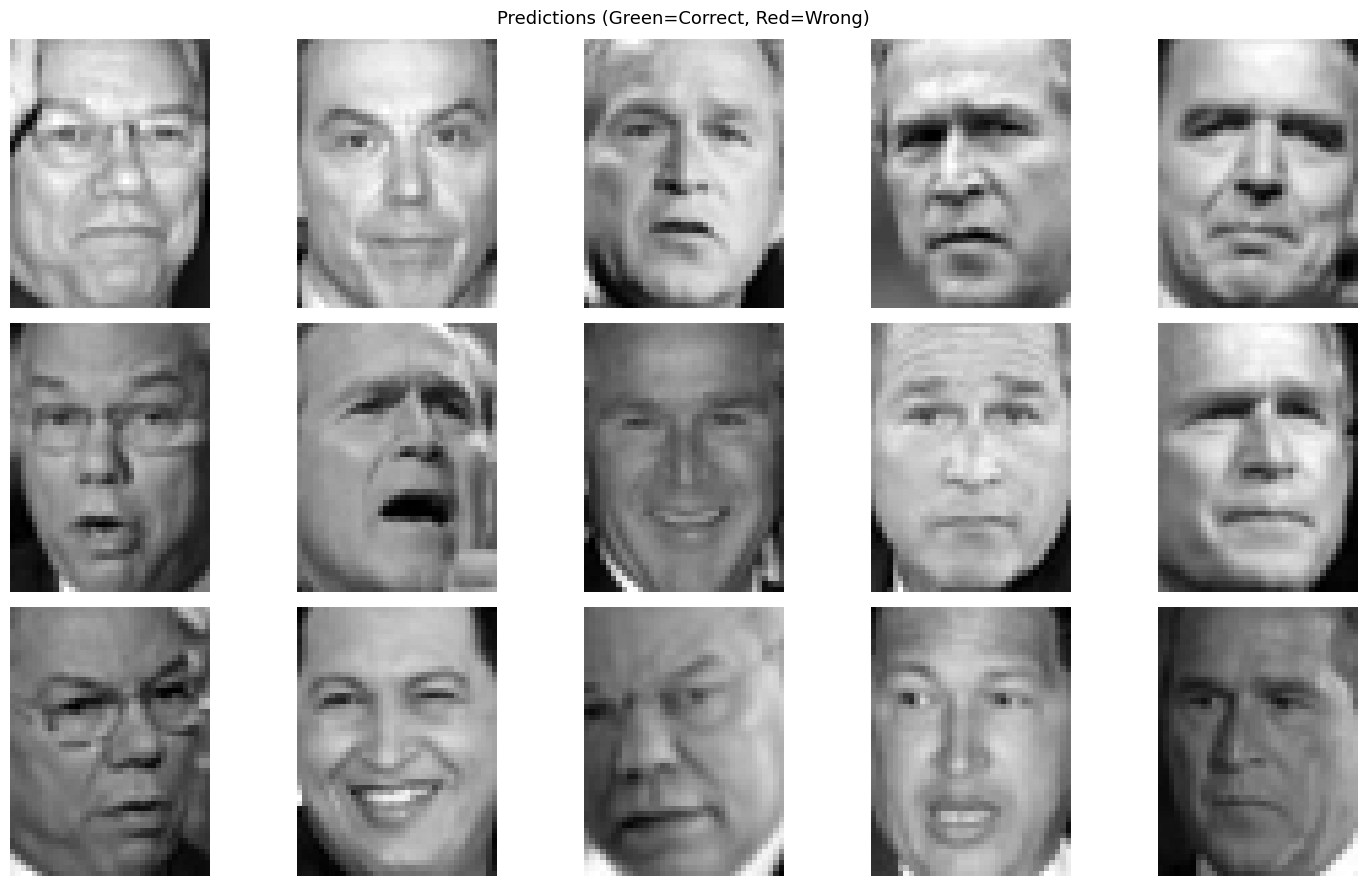

In [ ]:
predictions = best_model.predict(x_test[:15])

plt.figure(figsize=(15, 9))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(x_test[i].reshape(50, 37), cmap='gray')
    pred  = short_names[np.argmax(predictions[i])]
    actual = short_names[y_test[i]]
    color = 'green' if pred == actual else 'red'
    plt.xlabel(f"Pred: {pred}\nActual: {actual}", color=color, fontsize=8)
    plt.axis('off')
plt.suptitle("Predictions (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()